# 09 — Training the CryNet Architecture
## Deep Learning Pipeline with Advanced Regularization

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.utils import set_plot_style, CLEANED_DIR, NOISY_DIR
from src.dl_data import discover_audio_for_dl, create_data_loaders
from src.dl_model import CryNet
from src.dl_train import train_model

set_plot_style()
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print("Device:", device)

Device: mps


In [2]:
# Discover and split data
file_paths, labels, label_names = discover_audio_for_dl([CLEANED_DIR, NOISY_DIR])

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

train_loader, val_loader, train_dataset, val_dataset = create_data_loaders(
    train_paths, train_labels, val_paths, val_labels,
    class_names=label_names, batch_size=32, num_workers=0
)

class_weights = train_dataset.get_class_weights()
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 1686
Validation samples: 422


In [3]:
# Initialize and train CryNet
model = CryNet(n_classes=len(label_names), n_mels=128, dropout=0.3)
total, trainable = model.count_parameters()
print("CryNet Parameters:", f"{total:,}")

print("\nStarting CryNet Training...")
trained_model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    n_epochs=80,
    base_lr=1e-3,
    warmup_epochs=5,
    patience=15,
    use_mixup=True,
    device=device,
    save_path='best_crynet.pth',
    verbose=True
)

CryNet Parameters: 1,749,096

Starting CryNet Training...


Training on device: mps
Total parameters: 1,749,096
Trainable parameters: 1,749,096
Epoch | Train Loss |   Val Loss | Train Acc |   Val Acc |   Val F1 |         LR
----------------------------------------------------------------------


    1 |     3.2320 |     1.9559 |    0.1400 |    0.0190 |   0.0091 |   0.000200


    2 |     2.5519 |     1.9845 |    0.1725 |    0.0237 |   0.0103 |   0.000400


    3 |     2.4811 |     1.9430 |    0.1779 |    0.0237 |   0.0109 |   0.000600


...

   55 |     1.1694 |     1.1367 |    0.3840 |    0.2346 |   0.2517 |   0.000251


   60 |     1.0019 |     1.0190 |    0.4099 |    0.2583 |   0.3400 |   0.000166


   65 |     1.1951 |     1.0594 |    0.4032 |    0.2583 |   0.3140 |   0.000096


   70 |     1.0371 |     1.0497 |    0.4513 |    0.2583 |   0.3147 |   0.000044


   75 |     0.9473 |     1.0453 |    0.4177 |    0.2630 |   0.3145 |   0.000012

Early stopping triggered at epoch 75
Best validation loss: 1.0190
Model saved to best_crynet.pth


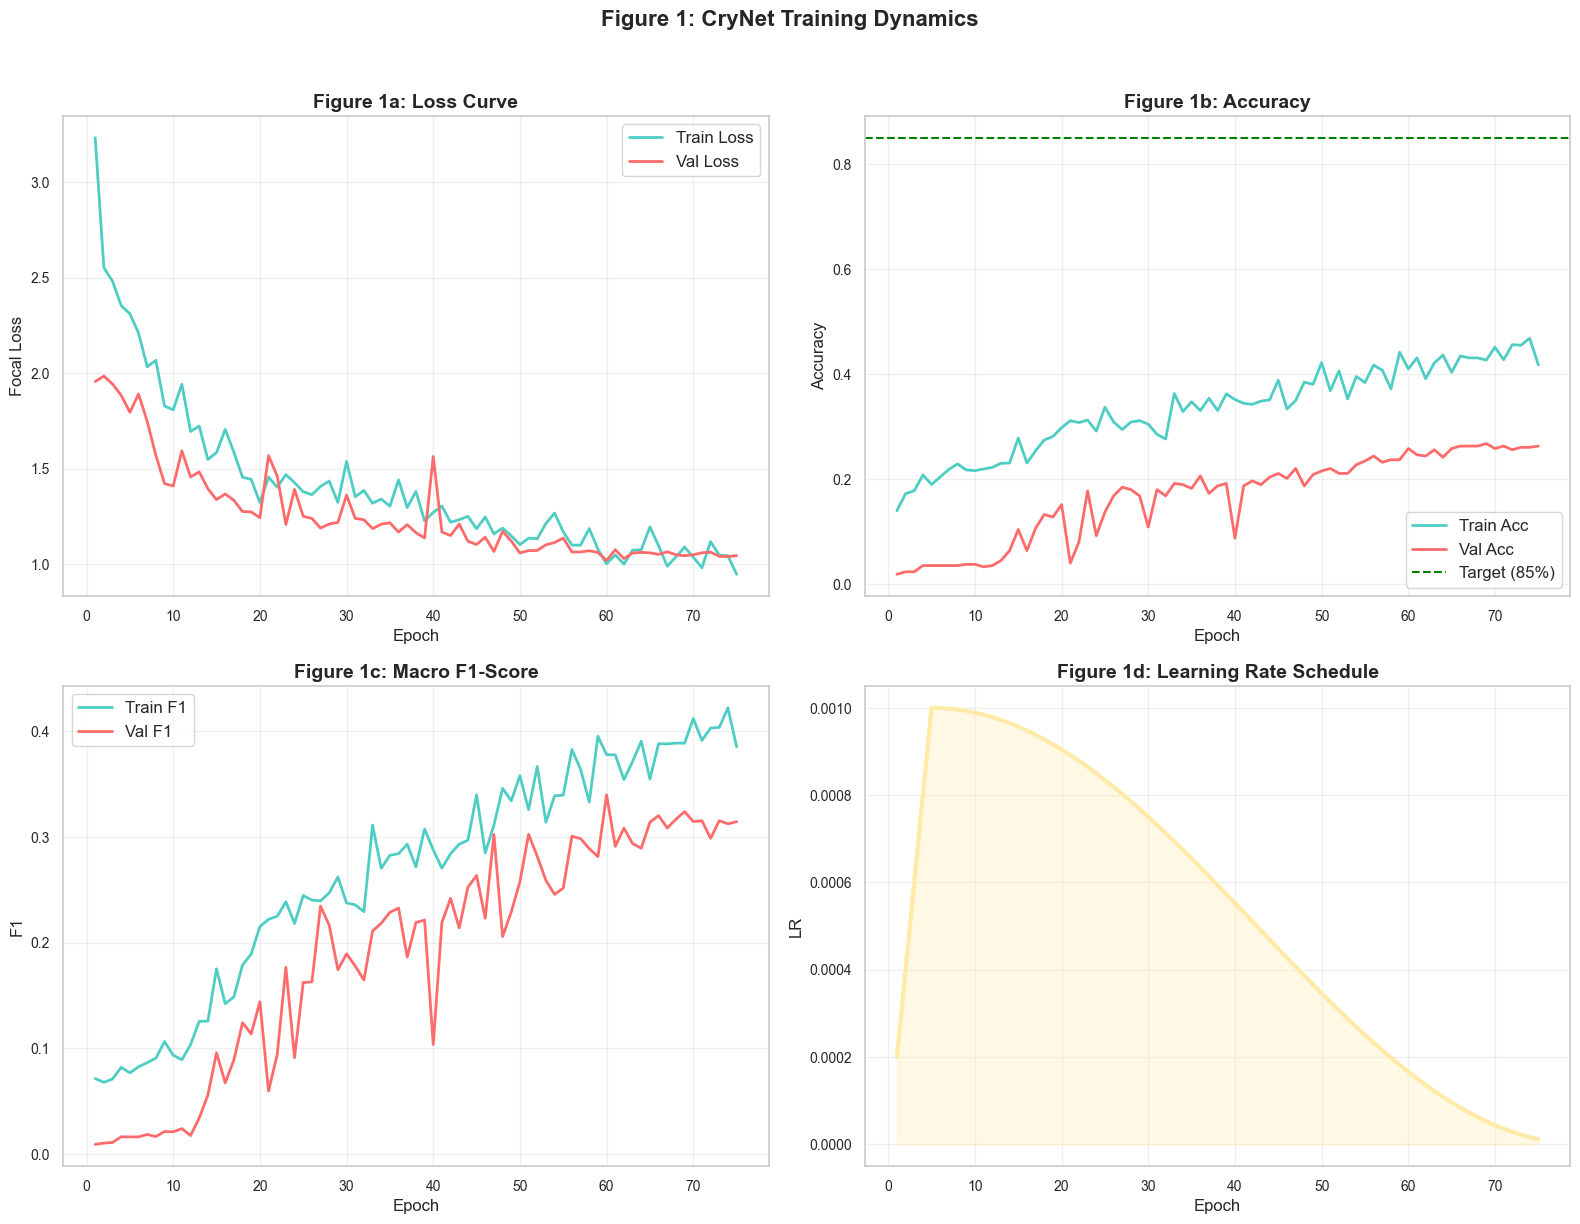

Best Val Accuracy: 0.2678
Best Val F1: 0.3400
Training Complete!


In [4]:
# ============================================================
# Figure 1: Training Progression
# ============================================================

history_dict = history.to_dict()
epochs = range(1, len(history_dict['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(epochs, history_dict['train_loss'], label='Train Loss', color='#4ECDC4', lw=2)
axes[0,0].plot(epochs, history_dict['val_loss'], label='Val Loss', color='#FF6B6B', lw=2)
axes[0,0].set_title('Figure 1a: Loss Curve', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Focal Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs, history_dict['train_acc'], label='Train Acc', color='#4ECDC4', lw=2)
axes[0,1].plot(epochs, history_dict['val_acc'], label='Val Acc', color='#FF6B6B', lw=2)
axes[0,1].axhline(y=0.85, color='green', linestyle='--', label='Target (85%)')
axes[0,1].set_title('Figure 1b: Accuracy', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(epochs, history_dict['train_f1'], label='Train F1', color='#4ECDC4', lw=2)
axes[1,0].plot(epochs, history_dict['val_f1'], label='Val F1', color='#FF6B6B', lw=2)
axes[1,0].set_title('Figure 1c: Macro F1-Score', fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('F1')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(epochs, history_dict['learning_rates'], color='#FFEAA7', lw=3)
axes[1,1].fill_between(epochs, history_dict['learning_rates'], alpha=0.3, color='#FFEAA7')
axes[1,1].set_title('Figure 1d: Learning Rate Schedule', fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('LR')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Figure 1: CryNet Training Dynamics", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Best Val Accuracy: {:.4f}".format(max(history_dict['val_acc'])))
print("Best Val F1: {:.4f}".format(max(history_dict['val_f1'])))
print("Training Complete!")